In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('titanic_limpio.csv')

In [3]:
df.head(2)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin datos,S,0
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


### EDAD (Explotatoy Data Analysis). Descubrimos cosas con los datos

In [4]:
type(df['Age'].values[0])  #saber el tipo de dato en una columna concreta

numpy.float64

In [5]:
df['Age'].shape  #saber la forma de una columna concreta

(891,)

In [6]:
edad = df['Age'] #crear una variable con la columna 'Age'

In [9]:
np.mean(edad)  #calcular la media de la columna 'Age'

np.float64(29.36158249158249)

In [20]:
np.std(edad)  #calcular la desviación típica de la columna 'Age'

np.float64(13.012388272793666)

In [22]:
resultado_formateado = f"{np.std(edad):.2f}"
print(resultado_formateado)  #formatear el resultado a 2 decimales

13.01


In [24]:
np.round(np.mean(edad), 2)

np.float64(29.36)

In [11]:
np.min(edad)  #calcular el valor mínimo de la columna 'Age'

np.float64(0.42)

In [12]:
np.max(edad)  #calcular el valor máximo de la columna 'Age'

np.float64(80.0)

In [13]:
np.median(edad)  #calcular la mediana de la columna 'Age'

np.float64(28.0)

<Axes: xlabel='Age', ylabel='Count'>

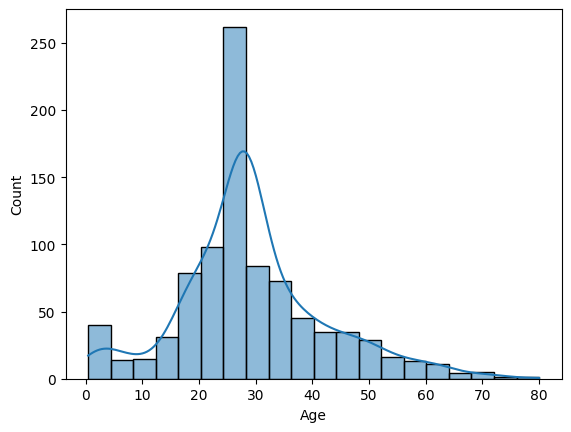

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(edad, bins=20, kde=True)  #histograma de la columna 'Age'

<Axes: xlabel='Age'>

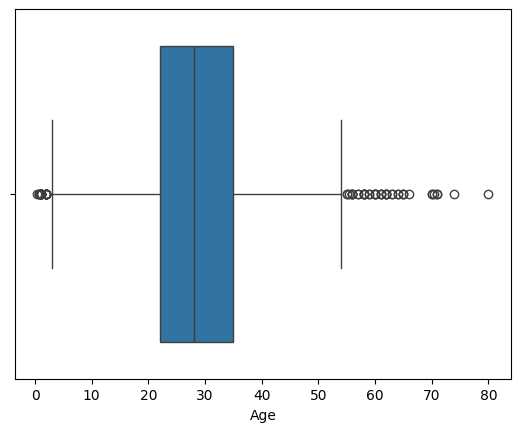

In [27]:
sns.boxplot(x=edad)  #boxplot de la columna 'Age'

#los puntos atípicos son los que están fuera de 1.5 veces el rango intercuartílico (IQR)
#el centro es 50, la linea de la izq 25 y la de la derecha 75
#el rango intercuartílico (IQR) es la diferencia entre el cuartil 75 y el cuartil 25
#el rango intercuartílico (IQR) es la distancia entre el cuartil 75 y el cuartil 25 

In [28]:
percentiles = np.percentile(edad, [25, 50, 75])
print(f"Percentiles: {percentiles}")  #calcular los percentiles de la columna 'Age'

Percentiles: [22. 28. 35.]


In [29]:
tarifa = df['Fare']  #crear una variable con la columna 'Fare'

In [33]:
percentiles = np.percentile(tarifa, [25, 50, 75])   
print(f"Percentiles: {percentiles}")  #calcular los percentiles de la columna 'Fare'
#Lo mas comun es que la gente pague entre 7 y 31 libras

Percentiles: [ 7.9104 14.4542 31.    ]


<Axes: xlabel='Fare'>

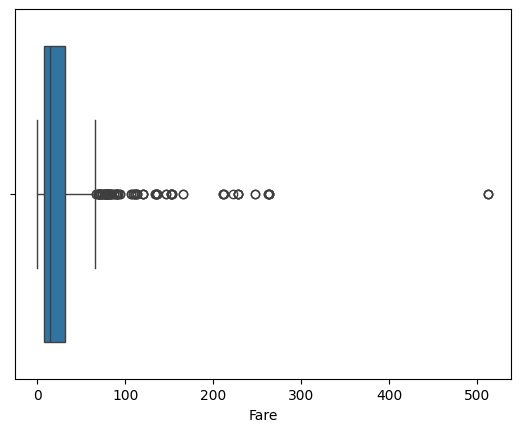

In [31]:
sns.boxplot(x=tarifa) 

<Axes: xlabel='Fare', ylabel='Count'>

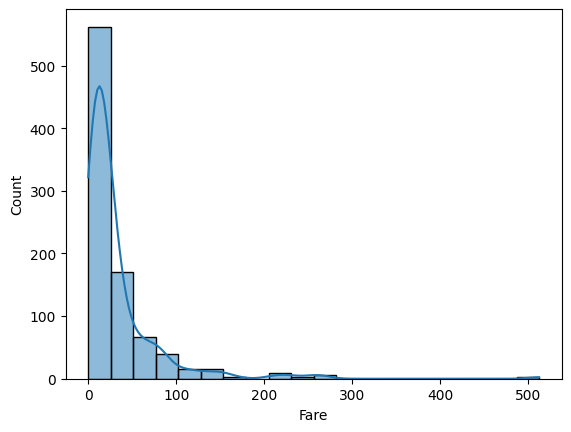

In [32]:
sns.histplot(tarifa, bins=20, kde=True)  #h

### Análisis supervivencia

In [35]:
df['Survived'].value_counts()  #contar los valores únicos de la columna 'Survived'
#0 = no sobrevivió, 1 = sobrevivió
# 0 es Falso y 1 es true

Survived
0    549
1    342
Name: count, dtype: int64

In [37]:
df['Survived'].mean() * 100  #calcular el porcentaje de supervivientes

np.float64(38.38383838383838)

In [43]:
tabla_clase = df.groupby('Pclass')['Survived'].agg(['count', 'mean', 'sum'])  #crear una tabla de supervivencia por clase  
tabla_clase.columns = ['Conteo', 'Media', 'Supervivientes']  #renombrar las columnas de la tabla
tabla_clase['Tasa'] = tabla_clase['Media'] * 100  #calcular la tasa de supervivencia
tabla_clase = tabla_clase.sort_index()
print(tabla_clase)  #imprimir la tabla de supervivencia por clase

        Conteo     Media  Supervivientes       Tasa
Pclass                                             
1          216  0.629630             136  62.962963
2          184  0.472826              87  47.282609
3          491  0.242363             119  24.236253


In [45]:
tabla_genero = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])  # crear una tabla de supervivencia por género
tabla_genero.columns = ['Toal', 'Sobrevivieron', 'Tasa']  # renombrar las columnas de la tabla
tabla_genero['Tasa'] = tabla_genero['Tasa'] * 100  # calcular la tasa de supervivencia
tabla_genero = tabla_genero.sort_index()
print(tabla_genero)  # imprimir la tabla de supervivencia por género

        Toal  Sobrevivieron       Tasa
Sex                                   
female   314            233  74.203822
male     577            109  18.890815


### Métodos de filtrado

In [46]:
mujeres = df[df['Sex'] == 'female']

In [47]:
mujeres

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Sin datos,S,0
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
8,8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Sin datos,S,0
9,9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Sin datos,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,Sin datos,S,0
882,882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,Sin datos,S,0
885,885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Sin datos,Q,0
887,887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1


### filtrado multivariable

In [52]:
hombres_primera_clase = df[(df['Sex'] == 'male') & (df['Pclass'] == 1)]  #filtrar los hombres de primera clase]

In [53]:
hombres_primera_clase

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
6,6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
23,23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,1
27,27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,1
30,30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,Sin datos,C,0
34,34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,Sin datos,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,839,840,1,1,"Marechal, Mr. Pierre",male,28.0,0,0,11774,29.7000,C47,C,1
857,857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S,1
867,867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S,1
872,872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,1


In [54]:
ninos = df[df['Age'] < 12]      #filtrar los niños menores de 18 años

In [55]:
ninos

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
7,7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,Sin datos,S,0
10,10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,PP 9549,16.7000,G6,S,1
16,16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,Sin datos,Q,0
24,24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.00,3,1,349909,21.0750,Sin datos,S,0
43,43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,Sin datos,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,Sin datos,C,0
831,831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,Sin datos,S,0
850,850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.00,4,2,347082,31.2750,Sin datos,S,0
852,852,853,0,3,"Boulos, Miss. Nourelain",female,9.00,1,1,2678,15.2458,Sin datos,C,0


In [56]:
#Filtrado query

adultos_tercera = df.query('Age >= 18 and Pclass == 3')  #filtrar los adultos de tercera clase

In [57]:
adultos_tercera

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin datos,S,0
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Sin datos,S,0
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Sin datos,S,0
5,5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Sin datos,Q,0
8,8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Sin datos,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,Sin datos,S,0
884,884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,Sin datos,S,0
885,885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Sin datos,Q,0
888,888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Sin datos,S,0


In [58]:
#Categorización de una variable
df['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [63]:
def categorizar_tarifa(fare):
    if fare < 10:
        return 'Economica'
    elif fare < 30:
        return 'Moderada'
    else:
        return 'Alta'

In [64]:
df['Tarifa_Clasificada'] = df['Fare'].apply(categorizar_tarifa)  #crear una nueva columna con la tarifa clasificada

In [65]:
df

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina,Tarifa_Clasificada
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin datos,S,0,Economica
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Alta
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Sin datos,S,0,Economica
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Alta
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Sin datos,S,0,Economica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Sin datos,S,0,Moderada
887,887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Alta
888,888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Sin datos,S,0,Moderada
889,889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Alta
